# Exploratory analysis of the Slope Unit types — Aburrá Valley

Descriptive, publication-style figures characterising the three Slope Unit (SU) types
obtained with the GMM clustering, and their relationship with landslides and rainfall.

**Input:** `slope_units_final_mm.gpkg` (61,073 SU, CRS EPSG:3116, metres).
Key columns: `su_type` (1–3), `slope_mean`, `curva_mean`, `aspect_mea`,
`n_mm` (landslides per SU), `zona_lluvia` (rainfall zone, 1–5).

**Figures**
1. Box plot — mean slope by type
2. Box plot — mean curvature by type
3. Rose (polar) diagrams — aspect by type
4. Scatter — slope vs curvature, coloured by type
5. Bar chart — relative abundance (% units and % area) by type
6. Bar chart — landslide density (events km⁻²) by type
7. Scatter — rainfall (duration vs intensity) by type, zone and density *(needs rainfall columns)*

All SU types use the same colours as the map (Okabe–Ito, colour-blind safe).

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ----------------------------------------------------------------------
# Slope Unit types: labels and colour-blind-safe colours (match the map)
# ----------------------------------------------------------------------
SU_LABELS = {
    1: "Steep concave–convex slopes",
    2: "Intermediate concave–convex slopes",
    3: "Steep concave slopes",
}
SU_COLORS = {1: "#E69F00", 2: "#009E73", 3: "#D81B60"}   # Okabe–Ito
SU_SHORT  = {1: "SU 1", 2: "SU 2", 3: "SU 3"}
TYPES = [1, 2, 3]

# ----------------------------------------------------------------------
# Paths  (adjust GPKG_PATH to your machine if needed)
# ----------------------------------------------------------------------
#GPKG_PATH = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final_mm.gpkg"
GPKG_PATH = "slope_units_final_mm_rain.gpkg"
FIG_DIR   = "figs_eda"
os.makedirs(FIG_DIR, exist_ok=True)

SAVE_FIGS = True
DPI = 300

# ----------------------------------------------------------------------
# Publication style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "legend.frameon": False, "figure.dpi": 110, "savefig.bbox": "tight",
})

def _save(fig, name):
    if SAVE_FIGS:
        fig.savefig(os.path.join(FIG_DIR, name), dpi=DPI, facecolor="white")

In [2]:
# ----------------------------------------------------------------------
# Load the Slope Units and prepare derived columns
# ----------------------------------------------------------------------
gdf = gpd.read_file(GPKG_PATH)
gdf = gdf[gdf["su_type"].isin(TYPES)].copy()

assert gdf.crs is not None and not gdf.crs.is_geographic, \
    "A projected CRS (metres) is required to compute areas."

gdf["area_km2"]     = gdf.geometry.area / 1e6     # km^2 per SU
gdf["curva_mean_k"] = gdf["curva_mean"] * 1e3     # curvature in 1e-3 units (readability)

print(f"Slope Units loaded: {len(gdf):,}")
print(gdf["su_type"].value_counts().sort_index())

Slope Units loaded: 61,242
su_type
1    31636
2    23012
3     6594
Name: count, dtype: int64


In [3]:
# ----------------------------------------------------------------------
# Per-type summary table (printed; also useful for the thesis text)
# ----------------------------------------------------------------------
summary = (gdf.groupby("su_type")
              .agg(n_units=("su_type", "size"),
                   area_km2=("area_km2", "sum"),
                   slope_mean=("slope_mean", "mean"),
                   slope_sd=("slope_mean", "std"),
                   curv_mean=("curva_mean", "mean"),
                   curv_sd=("curva_mean", "std"),
                   n_landslides=("n_mm", "sum")))
summary["pct_units"] = 100 * summary["n_units"] / summary["n_units"].sum()
summary["pct_area"]  = 100 * summary["area_km2"] / summary["area_km2"].sum()
summary["dens_km2"]  = summary["n_landslides"] / summary["area_km2"]
summary.round(3)

,n_units,area_km2,slope_mean,slope_sd,curv_mean,curv_sd,n_landslides,pct_units,pct_area,dens_km2
su_type,,,,,,,,,,
1,31636,575.558,30.309,4.898,0.000,0.001,4668,51.657,57.157,8.110
2,23012,383.844,16.804,3.697,-0.000,0.001,1209,37.576,38.118,3.150
3,6594,47.576,27.674,8.445,-0.003,0.003,321,10.767,4.725,6.747


## 1. Morphometric signature of each type
### Figure 1 — Slope distribution (box plots)

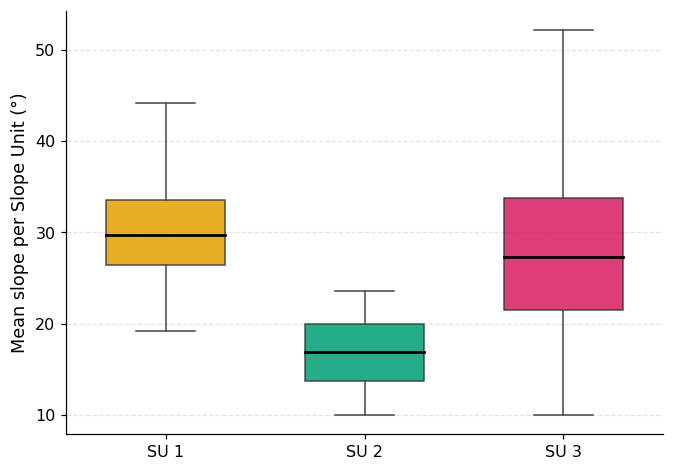

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
data = [gdf.loc[gdf.su_type == t, "slope_mean"] for t in TYPES]
bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False,
                medianprops=dict(color="black", linewidth=1.8),
                whiskerprops=dict(color="#444"), capprops=dict(color="#444"))
for patch, t in zip(bp["boxes"], TYPES):
    patch.set_facecolor(SU_COLORS[t]); patch.set_alpha(0.85); patch.set_edgecolor("#333")
ax.set_xticklabels([SU_SHORT[t] for t in TYPES])
ax.set_ylabel("Mean slope per Slope Unit (°)")
#ax.set_title("Slope distribution by Slope Unit type")
ax.grid(True, axis="y", ls="--", alpha=0.35); ax.set_axisbelow(True)
_save(fig, "fig1_box_slope.png"); plt.show()

### Figure 2 — Curvature distribution (box plots)
Curvature is shown in units of 10⁻³; negative = concave, positive = convex.

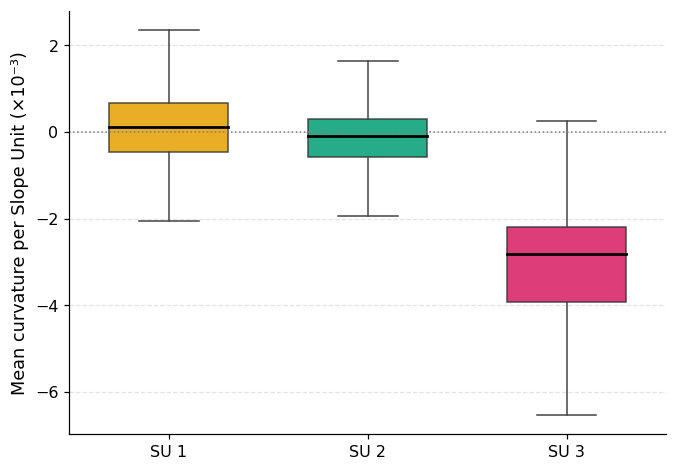

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
data = [gdf.loc[gdf.su_type == t, "curva_mean_k"] for t in TYPES]
bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False,
                medianprops=dict(color="black", linewidth=1.8),
                whiskerprops=dict(color="#444"), capprops=dict(color="#444"))
for patch, t in zip(bp["boxes"], TYPES):
    patch.set_facecolor(SU_COLORS[t]); patch.set_alpha(0.85); patch.set_edgecolor("#333")
ax.axhline(0, color="grey", lw=1, ls=":")
ax.set_xticklabels([SU_SHORT[t] for t in TYPES])
ax.set_ylabel("Mean curvature per Slope Unit (×10⁻³)")
#ax.set_title("Curvature distribution by Slope Unit type")
ax.grid(True, axis="y", ls="--", alpha=0.35); ax.set_axisbelow(True)
_save(fig, "fig2_box_curvature.png"); plt.show()

### Figure 3 — Aspect distribution (rose diagrams)
Aspect is a **circular** variable, so its distribution is shown as polar histograms
(16 sectors, North up, clockwise). Bars are the percentage of units in each sector.

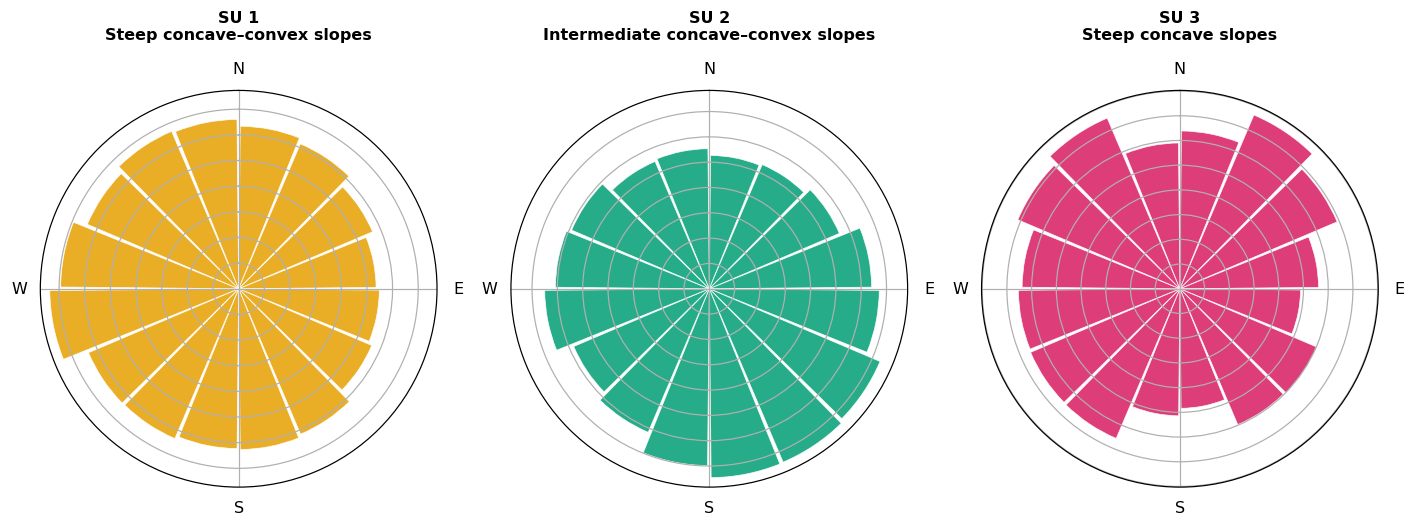

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), subplot_kw=dict(projection="polar"))
nbins = 16
bin_edges = np.linspace(0, 2*np.pi, nbins + 1)
width = 2*np.pi / nbins
centers = bin_edges[:-1] + width/2

for ax, t in zip(axes, TYPES):
    theta = np.deg2rad(gdf.loc[gdf.su_type == t, "aspect_mea"].values)
    counts, _ = np.histogram(theta, bins=bin_edges)
    frac = counts / counts.sum() * 100
    ax.bar(centers, frac, width=width*0.95, color=SU_COLORS[t],
           alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 90, 180, 270])); ax.set_xticklabels(["N", "E", "S", "W"])
    ax.set_title(f"{SU_SHORT[t]}\n{SU_LABELS[t]}", fontsize=10.5, pad=14)
    ax.set_yticklabels([])
#fig.suptitle("Aspect (orientation) distribution by Slope Unit type",
#             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
_save(fig, "fig3_rose_aspect.png"); plt.show()

### Figure 4 — Morphometric feature space (slope vs curvature)

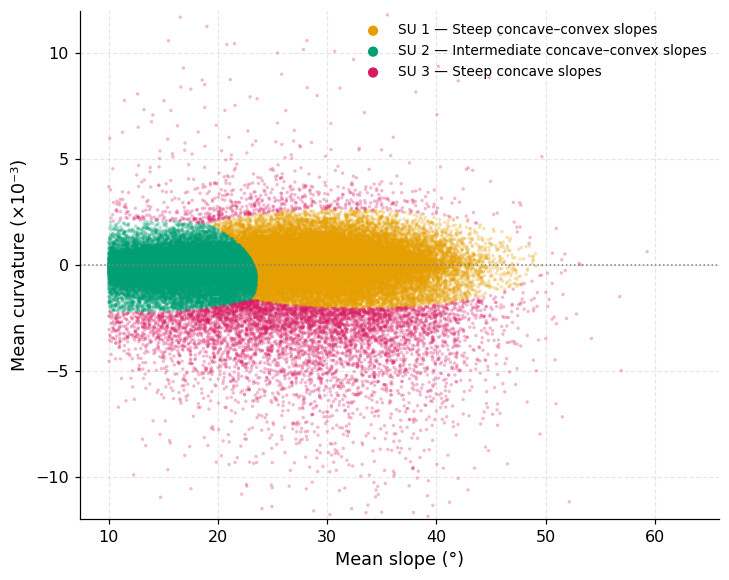

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for t in TYPES:  # larger clusters first, SU 3 on top
    sub = gdf[gdf.su_type == t]
    ax.scatter(sub["slope_mean"], sub["curva_mean_k"], s=5, c=SU_COLORS[t],
               alpha=0.30, edgecolors="none", rasterized=True,
               label=f"{SU_SHORT[t]} — {SU_LABELS[t]}")
ax.axhline(0, color="grey", lw=1, ls=":")
ax.set_xlabel("Mean slope (°)")
ax.set_ylabel("Mean curvature (×10⁻³)")
#ax.set_title("Morphometric feature space by Slope Unit type")
ax.set_ylim(-12, 12)
leg = ax.legend(markerscale=3, fontsize=9, loc="upper right")
for lh in leg.legend_handles:
    lh.set_alpha(1)
ax.grid(True, ls="--", alpha=0.3); ax.set_axisbelow(True)
_save(fig, "fig4_scatter_slope_curv.png"); plt.show()

## 2. Relative abundance of each type
### Figure 5 — Percentage of Slope Units by type

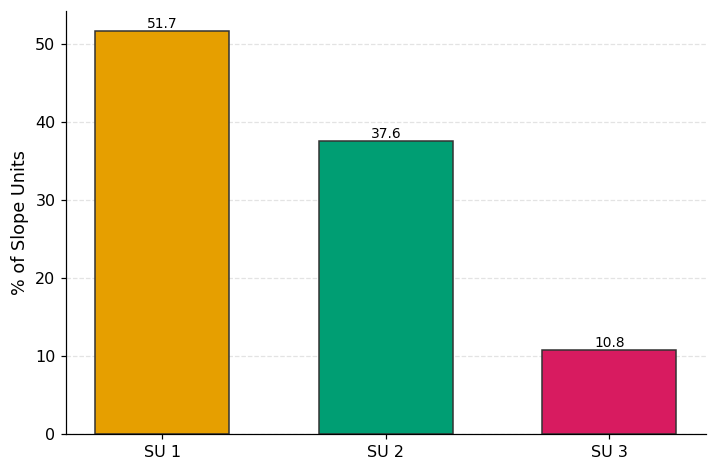

In [8]:
summ = gdf.groupby("su_type").agg(n=("su_type", "size"))
summ["pct_n"] = 100 * summ["n"] / summ["n"].sum()

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(3); w = 0.6
bars = ax.bar(x, summ["pct_n"], w,
              color=[SU_COLORS[t] for t in TYPES], edgecolor="#333")
for b in bars:
    ax.annotate(f"{b.get_height():.1f}", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([SU_SHORT[t] for t in TYPES])
ax.set_ylabel("% of Slope Units")
#ax.set_title("Relative abundance of Slope Unit types")
ax.grid(True, axis="y", ls="--", alpha=0.35); ax.set_axisbelow(True)
_save(fig, "fig5_bar_abundance.png"); plt.show()

## 3. Relationship with landslides
### Figure 6 — Landslide density by type
Density Dₜ = Nₜ / Aₜ (landslides per km² of each type).

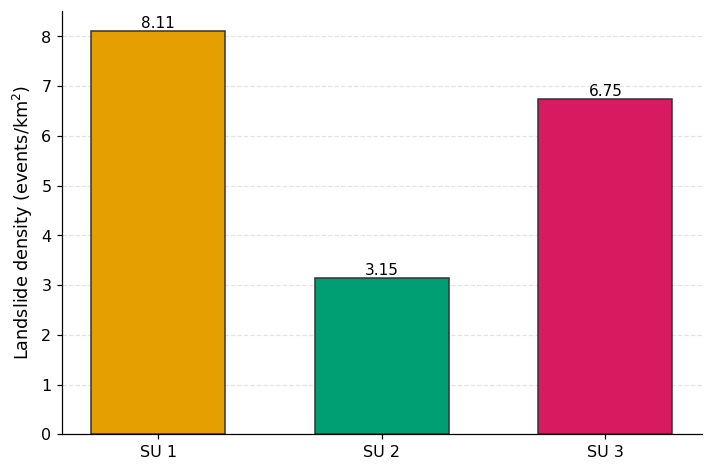

In [10]:
dens = gdf.groupby("su_type").agg(n_mm=("n_mm", "sum"), area=("area_km2", "sum"))
dens["d"] = dens["n_mm"] / dens["area"]

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(3)
bars = ax.bar(x, dens["d"], color=[SU_COLORS[t] for t in TYPES], edgecolor="#333", width=0.6)
for bar in bars:
    ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels([SU_SHORT[t] for t in TYPES])
ax.set_ylabel("Landslide density (events/km$^{2}$)")
#ax.set_title("Landslide density by Slope Unit type")
ax.grid(True, axis="y", ls="--", alpha=0.35); ax.set_axisbelow(True)
_save(fig, "fig6_bar_density.png"); plt.show()

## 4. Relationship with rainfall
### Figure 7 — Rainfall (duration vs intensity) by type, zone and density

This figure needs **rainfall descriptors per SU**, which are **not** stored in
`slope_units_final_mm.gpkg`. They are produced by the Chapter‑2 radar pipeline.
The expected columns are:

`duracion_promedio`, `intensidad_promedio`, `acumulado_promedio`,
`num_eventos`, `intensidad_maxima_promedio`.

Encoding in the figure:
- **colour** → Slope Unit type (`su_type`)
- **marker shape** → rainfall zone (`zona_lluvia`)
- **marker size** → landslide density (events km⁻²), binned by quartiles

If the columns are absent, the last cell prints how to obtain them. The optional
**Appendix** at the bottom reproduces the radar→SU enrichment.

In [31]:
# Rainfall descriptors expected in the SU layer
RAIN_COLS = ["duracion_promedio", "intensidad_promedio", "acumulado_promedio",
             "num_eventos", "intensidad_maxima_promedio"]

# Rainfall zones: markers and labels (verify the names against Chapter 2)
ZONE_MARKERS = {1: "o", 2: "s", 3: "^", 4: "D", 5: "P"}
ZONE_LABELS  = {1: "Oriente", 2: "Norte", 3: "Sur",
                4: "SAP", 5: "Occidente"}

def aggregate_by_type_and_zone(su_gdf, rain_cols, type_col="su_type", zone_col="zona_lluvia"):
    # Aggregate SU by (type, rainfall zone): mean rainfall descriptors,
    # summed landslides and area, and landslide density (events/km2).
    df = su_gdf.copy().dropna(subset=[type_col, zone_col])
    df[type_col] = df[type_col].astype(int)
    df[zone_col] = pd.to_numeric(df[zone_col], errors="coerce").round().astype("Int64")
    if "area_km2" not in df.columns:
        df["area_km2"] = df.geometry.area / 1e6
    agg = {c: "mean" for c in rain_cols}
    agg.update({"n_mm": "sum", "area_km2": "sum"})
    g = df.groupby([type_col, zone_col], as_index=False).agg(agg)
    g["dens_km2"] = g["n_mm"] / g["area_km2"].replace({0: np.nan})
    return g

def _size_by_density(values, levels=(60, 140, 260, 420)):
    # Map a density series to four marker sizes using quartile bins.
    x = pd.Series(values).replace([np.inf, -np.inf], np.nan).fillna(0)
    q1, q2, q3 = x.quantile([0.25, 0.50, 0.75])
    bins = [-np.inf, q1, q2, q3, np.inf]
    cats = pd.cut(x, bins=bins, labels=list(range(4)))
    sizes = cats.map(dict(zip(range(4), levels))).astype(float).values
    disp = [f"≤ {q1:.1f}", f"{q1:.1f}–{q2:.1f}", f"{q2:.1f}–{q3:.1f}", f"> {q3:.1f}"]
    return sizes, levels, disp
    
#xlabel="Mean event duration (h)",
#ylabel="Number of rainfall events",
def plot_rainfall_scatter(df_grp, x_col="num_eventos", y_col="intensidad_maxima_promedio",
                          xlabel="Number of rainfall events",
                          ylabel="Mean rainfall intensity (mm/h)",
                          savename="fig9_rainfall_scatter.png"):
    sizes, levels, disp = _size_by_density(df_grp["dens_km2"])
    fig, ax = plt.subplots(figsize=(9.5, 8.0))
    d = df_grp.reset_index(drop=True)
    for i, row in d.iterrows():
        t, z = int(row["su_type"]), int(row["zona_lluvia"])
        ax.scatter(row[x_col], row[y_col], s=sizes[i], c=SU_COLORS.get(t, "gray"),
                   marker=ZONE_MARKERS.get(z, "o"), edgecolor="k", linewidth=0.6, alpha=0.85)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, ls="--", alpha=0.3); ax.set_axisbelow(True)

    # --- legend proxies (Line2D -> predictable marker size in the legend) ---
    h_type = [mlines.Line2D([], [], color=SU_COLORS[t], marker="o", ls="None", ms=9,
              mec="k", label=f"{SU_SHORT[t]} — {SU_LABELS[t]}") for t in TYPES]
    h_zone = [mlines.Line2D([], [], color="0.4", marker=ZONE_MARKERS[z], ls="None", ms=9,
              mec="k", label=ZONE_LABELS.get(z, f"Zone {z}")) for z in sorted(ZONE_MARKERS)]
    h_size = [mlines.Line2D([], [], color="lightgray", marker="o", ls="None", mec="k",
              ms=np.sqrt(levels[i]), label=disp[i]) for i in range(4)]

    # --- three legends stacked in a band right below the x-axis ---
    fig.subplots_adjust(left=0.10, right=0.97, top=0.97, bottom=0.30)
    leg1 = fig.legend(handles=h_type, title="Slope Unit type",
                      loc="upper center", bbox_to_anchor=(0.5, 0.245),
                      ncol=3, fontsize=9, title_fontsize=10, frameon=False,
                      handletextpad=0.5, columnspacing=1.6)
    leg2 = fig.legend(handles=h_zone, title="Rainfall zone",
                      loc="upper center", bbox_to_anchor=(0.5, 0.190),
                      ncol=5, fontsize=9, title_fontsize=10, frameon=False,
                      handletextpad=0.5, columnspacing=1.6)
    leg3 = fig.legend(handles=h_size, title="No. of landslides per km$^2$",
                      loc="upper center", bbox_to_anchor=(0.5, 0.130),
                      ncol=4, fontsize=9, title_fontsize=10, frameon=False,
                      columnspacing=3.0, handletextpad=1.0)
    _save(fig, savename); plt.show()

    su_type  zona_lluvia  duracion_promedio  intensidad_promedio  \
0         1            1              1.153                8.947   
1         1            2              1.263                8.618   
2         1            3              1.214                9.916   
3         1            4              1.258               10.214   
4         1            5              1.256                9.901   
5         2            1              1.177                9.008   
6         2            2              1.250                8.736   
7         2            3              1.219                9.859   
8         2            4              1.254               10.318   
9         2            5              1.270                9.473   
10        3            1              1.174                9.052   
11        3            2              1.265                8.577   
12        3            3              1.207                9.932   
13        3            4              1.253     

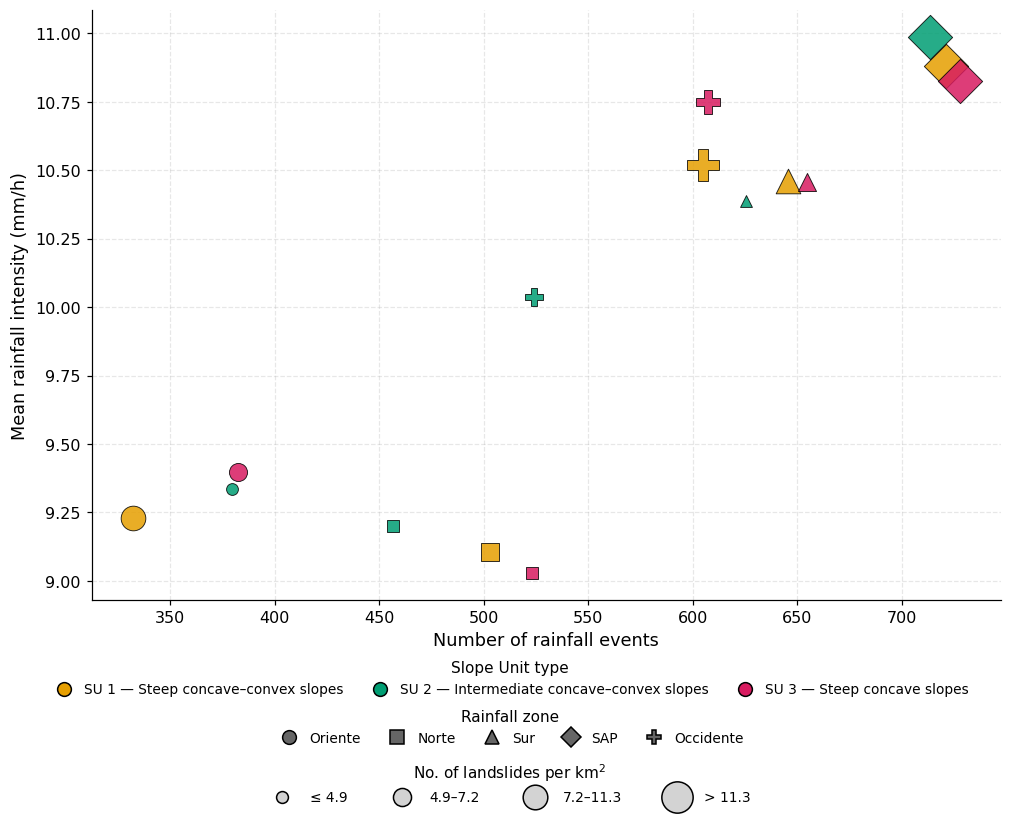

In [32]:
# Build Figure 7 if the rainfall descriptors are available, otherwise explain how to get them
if all(c in gdf.columns for c in RAIN_COLS):
    df_grp = aggregate_by_type_and_zone(gdf, RAIN_COLS)
    print(df_grp.round(3))
    plot_rainfall_scatter(df_grp)
else:
    missing = [c for c in RAIN_COLS if c not in gdf.columns]
    print("Rainfall descriptors not found in the SU layer:")
    print("  missing columns ->", missing)
    print("Run the Chapter-2 radar enrichment (see Appendix) to add these columns,")
    print("save the enriched layer, point GPKG_PATH to it, and re-run the notebook.")

---
## Appendix (optional) — Radar → Slope Unit rainfall enrichment

Reproduces, from the Chapter‑2 radar event NetCDF, the area‑weighted rainfall
descriptors per Slope Unit. **Requires** the radar NetCDF and the coordinate CSV.
Set `RUN_RAINFALL_ENRICHMENT = True` and edit the paths to run it. It writes an
enriched GeoPackage that you can then load as `GPKG_PATH` above.

In [23]:
RUN_RAINFALL_ENRICHMENT = False  # set True and edit paths to enrich the SU layer

if RUN_RAINFALL_ENRICHMENT:
    import xarray as xr
    from shapely.geometry import Polygon

    # --- paths (edit) ---
    RADAR_NC  = "BACK_PAPER_RainfallLandslides_Vdea copy/DATA/rainfall/radar/eventos_lluvia_5mm_1horas_2.nc"
    COORD_CSV = "BACK_PAPER_RainfallLandslides_Vdea copy/DATA/rainfall/radar/coordenadas_que_no.csv"
    OUT_GPKG  = "slope_units_final_mm_rain.gpkg"
    VAR_NAMES = ["num_eventos", "intensidad_promedio", "duracion_promedio",
                 "acumulado_promedio", "intensidad_maxima_promedio"]

    def filter_and_interpolate(radar_file, coord_file):
        coords = pd.read_csv(coord_file)
        data = xr.open_dataset(radar_file)
        mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool),
                            coords=[data.lon, data.lat], dims=["lon", "lat"])
        for lo, la in zip(coords["lon"].values, coords["lat"].values):
            nlon = data.sel(lon=lo, method="nearest").lon.values
            nlat = data.sel(lat=la, method="nearest").lat.values
            mask.loc[nlon, nlat] = False
        ds = data.where(mask, drop=True)
        ds = ds.interpolate_na(dim="lon", method="linear")
        ds = ds.interpolate_na(dim="lat", method="linear")
        return ds

    def ds_to_points(ds, var_names, crs):
        lon = ds["lon"].values; lat = ds["lat"].values
        LON, LAT = np.meshgrid(lon, lat, indexing="xy")
        cols = {}
        for v in var_names:
            arr = np.squeeze(ds[v].values)
            if arr.shape != LON.shape and arr.T.shape == LON.shape:
                arr = arr.T
            cols[v] = arr.ravel()
        df = pd.DataFrame({"lon": LON.ravel(), "lat": LAT.ravel(), **cols}).dropna(subset=var_names, how="all")
        pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326")
        return pts.to_crs(crs)

    def area_weighted_rain(su, pts, var_names):
        xs = np.sort(pts.geometry.x.values); ys = np.sort(pts.geometry.y.values)
        hx = 0.5 * np.median(np.diff(xs)[np.diff(xs) > 0])
        hy = 0.5 * np.median(np.diff(ys)[np.diff(ys) > 0])
        polys = [Polygon([(p.x-hx, p.y-hy), (p.x+hx, p.y-hy),
                          (p.x+hx, p.y+hy), (p.x-hx, p.y+hy)]) for p in pts.geometry]
        cells = pts[var_names].copy(); cells["geometry"] = polys
        cells = gpd.GeoDataFrame(cells, geometry="geometry", crs=su.crs)
        su = su.copy(); su["su_idx"] = su.index; su["geometry"] = su.geometry.buffer(0)
        inter = gpd.overlay(cells, su[["su_idx", "geometry"]], how="intersection")
        inter["w"] = inter.area
        out = {}
        for sid, grp in inter.groupby("su_idx"):
            w = grp["w"].to_numpy(); W = np.nansum(w)
            out[sid] = {v: (np.nansum(grp[v].to_numpy() * w) / W if W > 0 else np.nan) for v in var_names}
        res = pd.DataFrame(out).T
        for v in var_names:
            su.loc[res.index, v] = res[v]
        return su

    su = gpd.read_file(GPKG_PATH).to_crs("EPSG:3116")
    ds = filter_and_interpolate(RADAR_NC, COORD_CSV)
    pts = ds_to_points(ds, VAR_NAMES, su.crs)
    su_rain = area_weighted_rain(su, pts, VAR_NAMES)
    su_rain.to_file(OUT_GPKG, driver="GPKG")
    print(f"Enriched layer written to {OUT_GPKG}. Set GPKG_PATH to it and re-run.")
else:
    print("Set RUN_RAINFALL_ENRICHMENT = True (and edit the paths) to run the enrichment.")

Set RUN_RAINFALL_ENRICHMENT = True (and edit the paths) to run the enrichment.
